# Trilha A — Regressão linear

A fase 1 testa três metodologias na mesma régua: regressão linear, gradient boosting e rede neural. Esta trilha vem primeiro por método, não por cronologia.

Quando o alvo é um número, a regressão linear é o ponto de partida porque é o único modelo que se explica sozinho. Ela entrega um piso de comparação, coeficientes em unidades do negócio e — o que mais importa aqui — um diagnóstico: suas suposições são verificáveis uma a uma, e cada uma que falha indica qual modelo deve vir depois.

O papel desta trilha é construir esse argumento. Ao final, as escolhas de modelagem do projeto estarão ancoradas em medidas feitas aqui.

| suposição | significado | teste | seção |
|---|---|---|---|
| preditores honestos | nada que só se saiba depois do dia | com e sem preço | § 4 |
| erro de tamanho constante | mesma dispersão em toda a faixa | desvio do resíduo por faixa | § 5 |
| aditividade | o efeito da epidemia é o mesmo em toda categoria | vão entre as retas; erro por combinação | § 3, § 6 |
| alvo = média | prever o valor esperado basta | serviço atingido pela média | § 8 |

Três dessas quatro falham.

## 1. O modelo

Mesma régua das demais trilhas: split temporal (últimos 120 dias como teste), preditores honestos (contexto do dia e calendário, sem preço nem histórico) e RMSSE como métrica. As categóricas entram por *one-hot*.

22 colunas depois do one-hot · R² no treino = 0.396

+-----------------------------+---------+-------+
| modelo                      |   RMSSE |   MAE |
+=============================+=========+=======+
| naïve (lag 1)               |  0.9542 | 39.64 |
+-----------------------------+---------+-------+
| naïve sazonal (lag 7)       |  1.0252 | 42.78 |
+-----------------------------+---------+-------+
| média do SKU                |  0.7967 | 34.04 |
+-----------------------------+---------+-------+
| Regressão linear (Trilha A) |  0.6488 | 27.12 |
+-----------------------------+---------+-------+


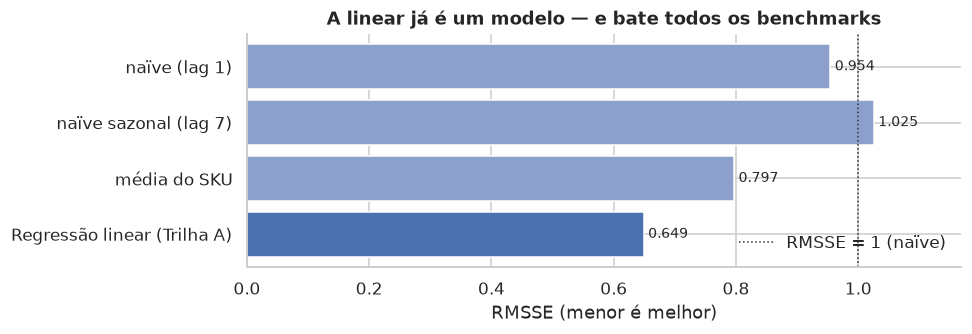

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import statsmodels.api as sm
import fase1_comum as C

sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"] = 110; plt.rcParams["axes.titleweight"] = "bold"

df = C.carregar(); treino, teste = C.split(df)

def desenho(d, features, colunas=None):
    "Matriz de projeto: one-hot nas categóricas, numéricas como estão. `colunas` alinha teste ao treino."
    X = pd.get_dummies(d[features], drop_first=True, dtype=float)
    return X if colunas is None else X.reindex(columns=colunas, fill_value=0.0)

def ajusta_ols(features, tr=treino, te=teste):
    "Ajusta OLS no treino e devolve (modelo, previsão no treino, previsão no teste, nº de colunas)."
    A = desenho(tr, features); B = desenho(te, features, A.columns)
    m = sm.OLS(tr["demanda"].values, sm.add_constant(A.values)).fit()
    p_tr = np.maximum(m.predict(sm.add_constant(A.values)), 0)
    p_te = np.maximum(m.predict(sm.add_constant(B.values)), 0)
    return m, p_tr, p_te, A

ols, treino["pred_ols"], teste["pred_ols"], Xtr = ajusta_ols(C.FEATURES)
rmsse_A = C.rmsse_medio(teste, "pred_ols", treino)

placar = C.benchmarks(treino, teste)
placar = pd.concat([placar, pd.DataFrame([{"modelo": "Regressão linear (Trilha A)", "RMSSE": round(rmsse_A, 4),
                    "MAE": round((teste["demanda"] - teste["pred_ols"]).abs().mean(), 2)}])], ignore_index=True)
print(f"{Xtr.shape[1]} colunas depois do one-hot · R² no treino = {ols.rsquared:.3f}\n")
print(placar.to_markdown(index=False, tablefmt="grid"))

fig, ax = plt.subplots(figsize=(9, 3.2))
b = ax.barh(placar["modelo"], placar["RMSSE"], color=["#8DA0CB"]*3 + ["#4C72B0"])
ax.bar_label(b, fmt="%.3f", padding=3, fontsize=9)
ax.axvline(1.0, color="#333", lw=1, ls=":", label="RMSSE = 1 (naïve)")
ax.set_xlabel("RMSSE (menor é melhor)"); ax.set_title("A linear já é um modelo — e bate todos os benchmarks")
ax.invert_yaxis(); ax.legend(frameon=False, loc="lower right"); ax.margins(x=0.14)
sns.despine(); plt.tight_layout(); plt.show()

São barras horizontais de RMSSE, e aqui **menor é melhor**. A linha pontilhada em 1,0 marca o desempenho de repetir o valor de ontem: qualquer barra à esquerda dela é melhor que não modelar nada. As três primeiras são os benchmarks; a última, a regressão.

A linear entrega **RMSSE 0,649** contra 0,797 do melhor benchmark. Não é um espantalho, é um modelo útil: o espaço que resta às trilhas seguintes é a distância entre 0,649 e o teto do dado.

O R² de 0,40 nos conta a outra metade. Sessenta por cento da variação não é explicada por uma combinação linear do contexto, e é a **forma** desse resto — não seu tamanho — que vai decidir qual modelo vem depois.

## 2. Os coeficientes

Cada coeficiente é um efeito em unidades vendidas, com o restante do contexto fixo. A fase 0a mediu os mesmos efeitos por médias condicionais; aqui eles saem de um ajuste simultâneo.

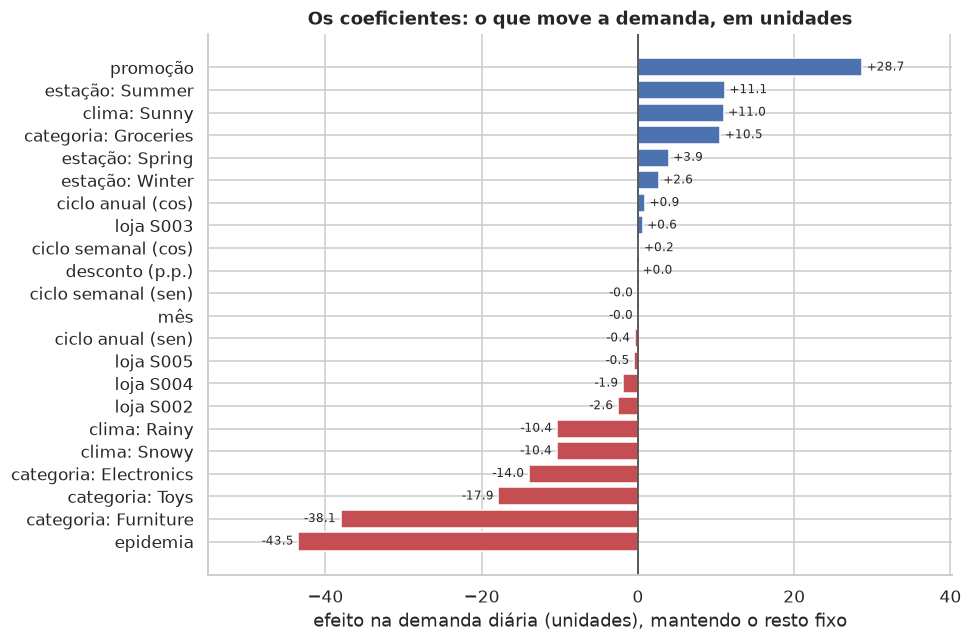

Demanda média do painel: 104.3 un./dia

  epidemia     -43.5 un.  (-42% da média)
  promoção     +28.7 un.  (+28% da média)


In [2]:
coef = pd.Series(ols.params[1:], index=Xtr.columns)
nomes = {"epidemia": "epidemia", "promocao": "promoção", "desconto": "desconto (p.p.)",
         "cal_ano_sin": "ciclo anual (sen)", "cal_ano_cos": "ciclo anual (cos)",
         "cal_sem_sin": "ciclo semanal (sen)", "cal_sem_cos": "ciclo semanal (cos)", "mes": "mês"}
rotulo = lambda c: nomes.get(c, c.replace("categoria_", "categoria: ").replace("clima_", "clima: ")
                                .replace("estacao_", "estação: ").replace("loja_", "loja "))
c_ord = coef.sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
cores = ["#C44E52" if v < 0 else "#4C72B0" for v in c_ord]
b = ax.barh([rotulo(i) for i in c_ord.index], c_ord.values, color=cores)
ax.bar_label(b, fmt="%+.1f", padding=3, fontsize=8)
ax.axvline(0, color="#333", lw=1)
ax.set_xlabel("efeito na demanda diária (unidades), mantendo o resto fixo")
ax.set_title("Os coeficientes: o que move a demanda, em unidades")
ax.margins(x=0.16); sns.despine(); plt.tight_layout(); plt.show()

media = df["demanda"].mean()
print(f"Demanda média do painel: {media:.1f} un./dia\n")
for k in ["epidemia", "promocao"]:
    print(f"  {rotulo(k):<10} {coef[k]:+7.1f} un.  ({coef[k]/media:+.0%} da média)")

Cada barra é um coeficiente, em **unidades de demanda por dia**, com o restante do contexto mantido fixo. Azul soma, vermelho subtrai, e o comprimento é o tamanho do efeito; os coeficientes das categóricas são sempre relativos ao nível de referência que o *one-hot* omite.

Reencontramos os dois fatores dominantes com sinal e magnitude: epidemia **−43 un./dia** e promoção **+29 un./dia**, ou −42% e +28% da média do painel. A fase 0a chegara a −38% e +30% por outro caminho, o que nos indica efeitos grandes e pouco dependentes do restante do contexto.

Abaixo deles vem a estrutura de sortimento (`Furniture` −38 un., `Groceries` +11) e efeitos ambientais coerentes (sol +11, neve −10, verão +11). Os coeficientes de **loja são próximos de zero**: as cinco lojas se comportam igual depois de ajustado o contexto. Nenhum modelo posterior nos dará uma tabela tão legível quanto esta.

## 3. As relações aprendidas

Ler coeficiente não é ver a relação. Quatro gráficos mostram o modelo por dentro: quanto ele acerta, como monta uma previsão, que forma é capaz de desenhar e o que encontrou no calendário.

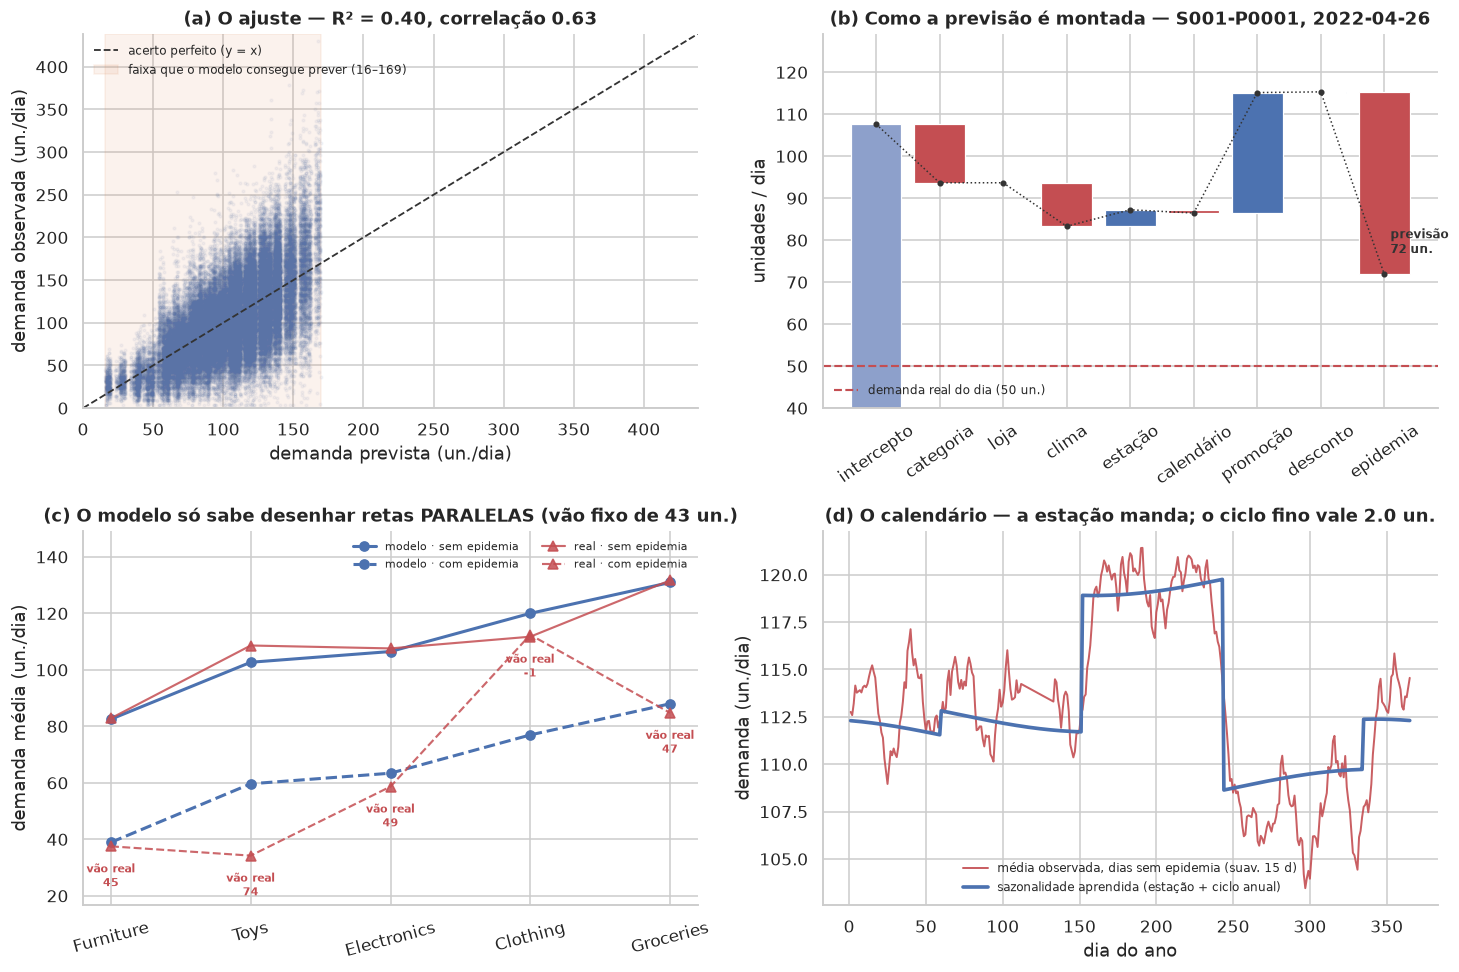

(a) faixa prevista 16–169 un.  |  faixa observada 4–430 un.
(c) vão epidemia — modelo: ['44', '43', '43', '43', '43']  (constante, por construção)
(c) vão epidemia — real:   ['45', '74', '49', '-1', '47']  (varia de -1 a 74)
(d) amplitude do ciclo anual fino: 1.96 un.  |  do ciclo semanal: 0.39 un.


In [3]:
const = ols.params[0]
coef_ = pd.Series(ols.params[1:], index=Xtr.columns)

fig, ax = plt.subplots(2, 2, figsize=(13.5, 9))

# ---------------------------------------------------- (a) previsto × observado
a = ax[0, 0]
a.scatter(treino["pred_ols"], treino["demanda"], s=3, alpha=0.06, color="#4C72B0", rasterized=True)
lim = [0, max(treino["demanda"].max(), treino["pred_ols"].max()) * 1.02]
a.plot(lim, lim, color="#333", lw=1.2, ls="--", label="acerto perfeito (y = x)")
a.axvspan(treino["pred_ols"].min(), treino["pred_ols"].max(), color="#DD8452", alpha=0.10,
          label=f"faixa que o modelo consegue prever ({treino['pred_ols'].min():.0f}–{treino['pred_ols'].max():.0f})")
a.set_xlim(0, lim[1]); a.set_ylim(0, lim[1])
a.set_xlabel("demanda prevista (un./dia)"); a.set_ylabel("demanda observada (un./dia)")
a.set_title(f"(a) O ajuste — R² = {ols.rsquared:.2f}, correlação {treino['pred_ols'].corr(treino['demanda']):.2f}")
a.legend(frameon=False, fontsize=8, loc="upper left")

# ---------------------------------------------------- (b) como uma previsão é montada
a = ax[0, 1]
i = treino.index[(treino["epidemia"] == 1) & (treino["promocao"] == 1)][0]
xi = Xtr.loc[i]
grupos = [("intercepto", None),
          ("categoria", [c for c in Xtr.columns if c.startswith("categoria_")]),
          ("loja", [c for c in Xtr.columns if c.startswith("loja_")]),
          ("clima", [c for c in Xtr.columns if c.startswith("clima_")]),
          ("estação", [c for c in Xtr.columns if c.startswith("estacao_")]),
          ("calendário", ["mes", "cal_ano_sin", "cal_ano_cos", "cal_sem_sin", "cal_sem_cos"]),
          ("promoção", ["promocao"]), ("desconto", ["desconto"]), ("epidemia", ["epidemia"])]
nomes = [g for g, _ in grupos]
vals = [const] + [float((coef_[c] * xi[c]).sum()) for _, c in grupos[1:]]
base_ = np.concatenate([[0], np.cumsum(vals)[:-1]])
cores_ = ["#8DA0CB"] + ["#4C72B0" if v >= 0 else "#C44E52" for v in vals[1:]]
a.bar(nomes, vals, bottom=base_, color=cores_, edgecolor="white", lw=0.8)
a.plot(nomes, np.cumsum(vals), color="#333", lw=1, ls=":", marker="o", ms=3, zorder=4)
a.axhline(treino.loc[i, "demanda"], color="#C44E52", lw=1.4, ls="--",
          label=f"demanda real do dia ({treino.loc[i,'demanda']:.0f} un.)")
a.annotate(f"previsão\n{treino.loc[i,'pred_ols']:.0f} un.", (len(nomes)-1, np.cumsum(vals)[-1]),
           textcoords="offset points", xytext=(4, 14), fontsize=8, weight="bold", color="#333")
a.set_ylim(40, max(np.cumsum(vals).max(), const) * 1.12)
a.set_ylabel("unidades / dia"); a.tick_params(axis="x", rotation=35)
a.set_title(f"(b) Como a previsão é montada — {treino.loc[i,'sku']}, {treino.loc[i,'data'].date()}")
a.legend(frameon=False, fontsize=8, loc="lower left")

# ---------------------------------------------------- (c) a forma que a linear SABE desenhar
a = ax[1, 0]
ordem = treino.groupby("categoria", observed=True)["demanda"].mean().sort_values().index.tolist()
prev = treino.groupby(["categoria", "epidemia"], observed=True)["pred_ols"].mean().unstack().reindex(ordem)
real = treino.groupby(["categoria", "epidemia"], observed=True)["demanda"].mean().unstack().reindex(ordem)
xx = np.arange(len(ordem))
a.plot(xx, prev[0], "-o", color="#4C72B0", lw=2, ms=6, label="modelo · sem epidemia")
a.plot(xx, prev[1], "-o", color="#4C72B0", lw=2, ms=6, ls="--", label="modelo · com epidemia")
a.plot(xx, real[0], "-^", color="#C44E52", lw=1.4, ms=6, alpha=0.85, label="real · sem epidemia")
a.plot(xx, real[1], "-^", color="#C44E52", lw=1.4, ms=6, ls="--", alpha=0.85, label="real · com epidemia")
for k in xx:
    vao = real[0].iloc[k] - real[1].iloc[k]
    a.annotate(f"vão real\n{vao:.0f}", (k, min(real[0].iloc[k], real[1].iloc[k])),
               textcoords="offset points", xytext=(0, -26), fontsize=7.5, color="#C44E52",
               ha="center", weight="bold")
a.margins(y=0.18)
a.set_xticks(xx); a.set_xticklabels(ordem, rotation=15)
a.set_ylabel("demanda média (un./dia)")
a.set_title(f"(c) O modelo só sabe desenhar retas PARALELAS "
            f"(vão fixo de {(prev[0]-prev[1]).mean():.0f} un.)")
a.legend(frameon=False, fontsize=7.5, ncol=2)

# ---------------------------------------------------- (d) o ano inteiro
a = ax[1, 1]
tr = treino.assign(doy=treino["data"].dt.dayofyear)
efeito_est = {e: (coef_.get(f"estacao_{e}", 0.0)) for e in treino["estacao"].unique()}
est_por_doy = tr.groupby("doy")["estacao"].agg(lambda s: s.mode().iloc[0])
doy = est_por_doy.index.values
# só dias SEM epidemia: senão o vale da epidemia seria lido como sazonalidade
obs = (tr[tr["epidemia"] == 0].groupby("doy")["demanda"].mean()
       .rolling(15, center=True, min_periods=1).mean())
est_doy = np.array([efeito_est[e] for e in est_por_doy.values])
sazonal = (obs.mean() - est_doy.mean() + est_doy
           + coef_["cal_ano_sin"] * np.sin(2*np.pi*doy/365.25)
           + coef_["cal_ano_cos"] * np.cos(2*np.pi*doy/365.25))
a.plot(obs.index, obs.values, color="#C44E52", lw=1.3, alpha=0.9,
       label="média observada, dias sem epidemia (suav. 15 d)")
a.plot(doy, sazonal, color="#4C72B0", lw=2.4, label="sazonalidade aprendida (estação + ciclo anual)")
a.set_xlabel("dia do ano"); a.set_ylabel("demanda (un./dia)")
amp_ciclo = (coef_["cal_ano_sin"]**2 + coef_["cal_ano_cos"]**2) ** 0.5 * 2
amp_sem = (coef_["cal_sem_sin"]**2 + coef_["cal_sem_cos"]**2) ** 0.5 * 2
a.set_title(f"(d) O calendário — a estação manda; o ciclo fino vale {amp_ciclo:.1f} un.")
a.legend(frameon=False, fontsize=8, loc="lower center")

sns.despine(fig=fig); plt.tight_layout(); plt.show()

print(f"(a) faixa prevista {treino['pred_ols'].min():.0f}–{treino['pred_ols'].max():.0f} un.  "
      f"|  faixa observada {treino['demanda'].min():.0f}–{treino['demanda'].max():.0f} un.")
print(f"(c) vão epidemia — modelo: {[f'{v:.0f}' for v in (prev[0]-prev[1])]}  (constante, por construção)")
print(f"(c) vão epidemia — real:   {[f'{v:.0f}' for v in (real[0]-real[1])]}  (varia de {(real[0]-real[1]).min():.0f} a {(real[0]-real[1]).max():.0f})")
print(f"(d) amplitude do ciclo anual fino: {amp_ciclo:.2f} un.  |  do ciclo semanal: {amp_sem:.2f} un.")

**(a) O ajuste.** A nuvem acompanha a diagonal, mas é larga e assimétrica. O modelo só produz previsões entre 16 e 169 unidades, enquanto a demanda observada vai de 4 a 430: uma regressão estima a média condicional, e média condicional não tem extremos. Os dias excepcionais ficam todos acima da diagonal, em território que o modelo não visita.

**(b) A montagem de uma previsão.** Num dia com promoção e epidemia, o modelo parte do intercepto (108 un.), desconta categoria e clima, aplica o calendário, soma a promoção (+29), subtrai a epidemia (−43) e chega a 72. É uma soma: nenhum termo depende de outro.

**(c) A forma disponível.** Em azul, o modelo desenha duas retas paralelas, com vão constante de 43 unidades entre dias com e sem epidemia. Isso não é um resultado, é uma imposição da estrutura aditiva — sendo `epidemia` um único coeficiente, o vão tem de ser igual em toda categoria.

Em vermelho, os vãos observados: 45, 74, 49, **−1** e 47. Em `Toys` a epidemia derruba 74 unidades; em `Clothing` não altera nada. A linha vermelha cruza a azul e volta, forma que nenhum ajuste de coeficientes desta família reproduz. A limitação é de estrutura, não de ajuste.

**(d) O calendário.** Os degraus de estação acompanham bem o nível anual, mas o ciclo anual fino vale **2,0 unidades** e o semanal **0,4** — não há efeito de dia da semana nesta demanda. O registro é relevante porque a M5, referência principal do projeto, é dominada por padrão semanal.

## 4. Diagnóstico I — o preço é vazamento

O dataset traz `preco`, e preço é o preditor clássico de demanda. A pergunta produtiva não é se ele ajuda, e sim **qual parte dele** ajuda. O preço de um SKU num dia tem dois componentes de estatuto distinto:

- o **nível de preço do item**, sua mediana histórica — característica estável, conhecida antes da previsão;
- o **desvio do dia** em relação a esse nível, que é o desconto praticado — só existe depois do fato.

Se o ganho vier do primeiro, é sinal legítimo. Se vier do segundo, é vazamento.

In [4]:
nivel = treino.groupby("sku")["preco"].median()          # estimado SÓ no treino, para não vazar o teste
for d in (treino, teste):
    d["preco_nivel"] = d["sku"].map(nivel)                # conhecido antes: característica do item
    d["preco_desvio"] = d["preco"] - d["preco_nivel"]     # só se sabe depois: o desconto do dia

linhas = []
for nome, extra in [("honesto (sem preço)", []),
                    ("+ nível de preço do SKU  ← conhecido antes", ["preco_nivel"]),
                    ("+ desvio do preço no dia ← só se sabe depois", ["preco_desvio"]),
                    ("+ preço bruto (os dois misturados)", ["preco"])]:
    m, _, p_te, A = ajusta_ols(C.FEATURES + extra)
    te = teste.assign(p=p_te)
    linhas.append({"preditores": nome, "R² treino": round(m.rsquared, 3),
                   "RMSSE teste": round(C.rmsse_medio(te, "p", treino), 4)})
tab = pd.DataFrame(linhas)
tab["ganho vs honesto"] = [f"{(rmsse_A - r)/rmsse_A:+.1%}" for r in tab["RMSSE teste"]]
print(tab.to_markdown(index=False, tablefmt="grid"))

# O mecanismo: o desconto do dia é decidido OLHANDO a demanda
faixa = pd.qcut(df["demanda"], 5, labels=["muito baixa", "baixa", "média", "alta", "muito alta"])
print("\nDesconto médio praticado, por faixa de demanda do dia:")
print(df.groupby(faixa, observed=True)["desconto"].mean().round(2).to_markdown(tablefmt="grid"))

# E o desconto, que ESTÁ no conjunto honesto? Mede-se inerte.
_, _, p_sem, _ = ajusta_ols([f for f in C.FEATURES if f != "desconto"])
print(f"\nControle — RMSSE sem a coluna `desconto`: {C.rmsse_medio(teste.assign(p=p_sem), 'p', treino):.4f} "
      f"(contra {rmsse_A:.4f} com ela)")

+----------------------------------------------+-------------+---------------+--------------------+
| preditores                                   |   R² treino |   RMSSE teste | ganho vs honesto   |
+==============================================+=============+===============+====================+
| honesto (sem preço)                          |       0.396 |        0.6488 | +0.0%              |
+----------------------------------------------+-------------+---------------+--------------------+
| + nível de preço do SKU  ← conhecido antes   |       0.396 |        0.6488 | +0.0%              |
+----------------------------------------------+-------------+---------------+--------------------+
| + desvio do preço no dia ← só se sabe depois |       0.748 |        0.4078 | +37.1%             |
+----------------------------------------------+-------------+---------------+--------------------+
| + preço bruto (os dois misturados)           |       0.44  |        0.619  | +4.6%              |


As duas metades dão respostas opostas.

O nível de preço do SKU vale **zero**: RMSSE 0,6488 com e sem ele. É coerente com a § 7 — a identidade do item não carrega sinal além da categoria.

O desvio do dia leva o RMSSE a **0,408**, uma melhora de **37%**, e o R² de 0,40 a 0,75. Seria o melhor modelo do projeto por margem que nem o boosting nem a rede disputam, e seria inútil: a tabela do desconto mostra que ele sobe monotonicamente com a demanda do dia. O desconto é consequência registrada, não decisão prévia; na manhã da previsão ele ainda não existe.

O preço bruto (0,619) é a mistura das duas partes. Aparenta um ganho modesto de 4,6% e, por isso mesmo, passaria sem exame. **A decomposição é o que converte um ganho suspeito em vazamento medido.**

Um registro de honestidade: a coluna `desconto` está no conjunto honesto e é informação do mesmo dia, com o mesmo problema em princípio. O controle mostra que ela é inerte — removê-la deixa o RMSSE idêntico, porque `promocao` já captura o efeito. O risco é nulo neste dataset, mas a coluna deveria sair por princípio.

O conjunto de preditores fica congelado aqui, e as Trilhas B e C usam o mesmo. O preço reaparece apenas na valoração em reais (§ 9), pela mediana estável por SKU.

## 5. Diagnóstico II — o erro não tem tamanho constante

A linear supõe homocedasticidade. Se isso falha, a previsão de ponto segue válida, mas qualquer margem de segurança calculada como média mais constante fica errada — folgada nos itens parados, apertada nos de giro alto, que são justamente os que rompem (fase 0b).

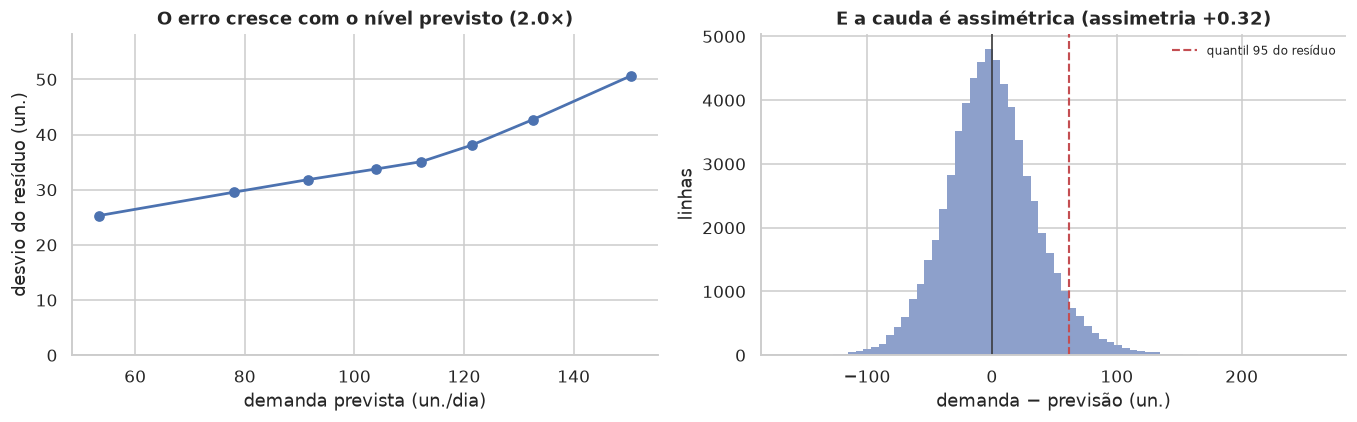

Desvio do resíduo no octil mais baixo:  25.3 un.
Desvio do resíduo no octil mais alto:   50.7 un.   → razão 2.0×
Assimetria do resíduo: +0.32 (cauda à direita: erra mais para baixo do que para cima)


In [5]:
res_tr = treino["demanda"] - treino["pred_ols"]
oct_ = pd.qcut(treino["pred_ols"], 8, duplicates="drop")
sd = res_tr.groupby(oct_, observed=True).std()
centro = treino["pred_ols"].groupby(oct_, observed=True).mean()
razao = sd.iloc[-1] / sd.iloc[0]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.5, 4))
a1.plot(centro.values, sd.values, "-o", color="#4C72B0", lw=1.8, ms=6)
a1.set_title(f"O erro cresce com o nível previsto ({razao:.1f}×)")
a1.set_xlabel("demanda prevista (un./dia)"); a1.set_ylabel("desvio do resíduo (un.)")
a1.set_ylim(0, sd.max()*1.15)

a2.hist(res_tr, bins=70, color="#8DA0CB", edgecolor="none")
a2.axvline(0, color="#333", lw=1)
a2.axvline(res_tr.quantile(0.95), color="#C44E52", lw=1.4, ls="--", label="quantil 95 do resíduo")
a2.set_title(f"E a cauda é assimétrica (assimetria {res_tr.skew():+.2f})")
a2.set_xlabel("demanda − previsão (un.)"); a2.set_ylabel("linhas"); a2.legend(frameon=False, fontsize=8)
sns.despine(); plt.tight_layout(); plt.show()

print(f"Desvio do resíduo no octil mais baixo:  {sd.iloc[0]:.1f} un.")
print(f"Desvio do resíduo no octil mais alto:   {sd.iloc[-1]:.1f} un.   → razão {razao:.1f}×")
print(f"Assimetria do resíduo: {res_tr.skew():+.2f} (cauda à direita: erra mais para baixo do que para cima)")

À esquerda vemos o desvio do resíduo em cada oitavo da faixa de previsão: **uma linha horizontal indicaria erro de tamanho constante**, que é o que a regressão supõe. À direita, a distribuição dos resíduos; se fosse simétrica, as duas metades em torno do zero seriam espelhadas.

A suposição falha de forma sistemática. O desvio do resíduo vai de 25 unidades no octil de menor giro a 51 no de maior, e a distribuição é assimétrica à direita: os erros grandes são desproporcionalmente casos de demanda acima do previsto.

Somando ao achado da fase 0b — quem rompe é o item de giro alto —, o erro é maior exatamente onde a ruptura acontece. Uma margem fixa estaria calibrada no lugar errado.

A margem precisa ser proporcional ao contexto, o que operacionalmente significa mirar um **quantil alto** em vez da média. Chegamos assim à conclusão da fase 0c por outro caminho, e as três trilhas a herdam pela calibração de resíduos por SKU (§ 9).

## 6. Diagnóstico III — os efeitos não se somam

A aditividade é a suposição central: o efeito da epidemia seria o mesmo, em unidades, em qualquer categoria. Se valesse, o erro médio de cada combinação de contexto seria nulo.

O painel (c) da § 3 já mostrou a falha em geometria. Esta seção a mede em RMSSE.

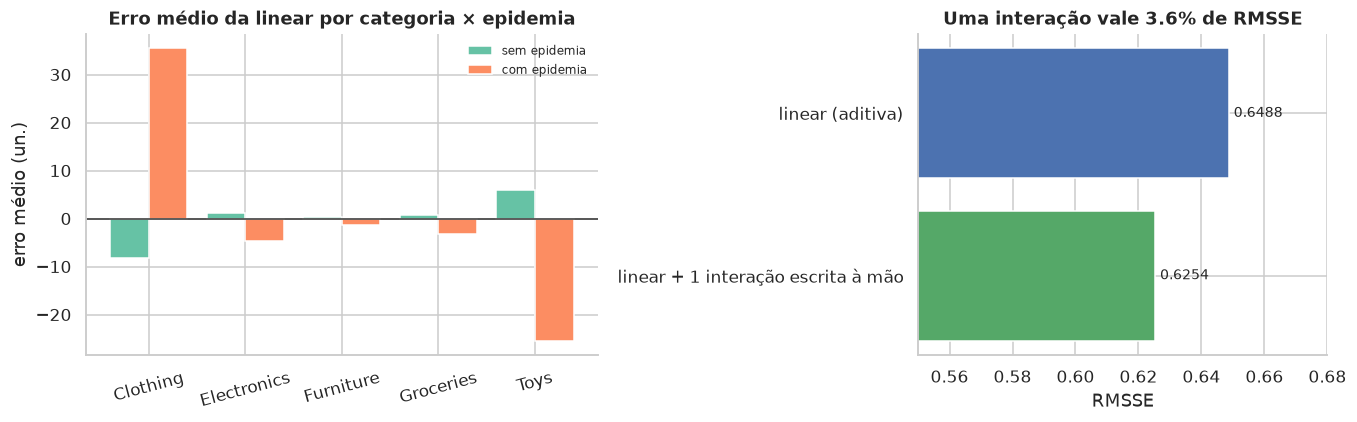

+-------------+----------------+----------------+
| categoria   |   sem epidemia |   com epidemia |
+=============+================+================+
| Clothing    |           -8.3 |           35.4 |
+-------------+----------------+----------------+
| Electronics |            1.1 |           -4.7 |
+-------------+----------------+----------------+
| Furniture   |            0.3 |           -1.4 |
+-------------+----------------+----------------+
| Groceries   |            0.7 |           -3.2 |
+-------------+----------------+----------------+
| Toys        |            5.9 |          -25.4 |
+-------------+----------------+----------------+

Maior viés: 35.4 un./dia — a linear erra sistematicamente esse canto do dado.
RMSSE aditiva 0.6488 → com 1 interação 0.6254  (+3.6%)


In [6]:
viés = res_tr.groupby([treino["categoria"], treino["epidemia"]], observed=True).mean().unstack()
viés.columns = ["sem epidemia", "com epidemia"]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.5, 4), gridspec_kw={"width_ratios": [1.25, 1]})
viés.plot(kind="bar", ax=a1, color=["#66C2A5", "#FC8D62"], width=0.8)
a1.axhline(0, color="#333", lw=1)
a1.set_title("Erro médio da linear por categoria × epidemia")
a1.set_ylabel("erro médio (un.)"); a1.set_xlabel(""); a1.tick_params(axis="x", rotation=15)
a1.legend(frameon=False, fontsize=8)

# Quanto custa essa única interação ignorada? Basta escrevê-la à mão e remedir.
for d in (treino, teste):
    d["cat_epi"] = d["categoria"].astype(str) + "·" + d["epidemia"].astype(str)
m_i, _, teste["pred_inter"], Xi = ajusta_ols(C.FEATURES + ["cat_epi"])
rmsse_inter = C.rmsse_medio(teste, "pred_inter", treino)

cmp = pd.DataFrame({"modelo": ["linear (aditiva)", "linear + 1 interação escrita à mão"],
                    "RMSSE": [round(rmsse_A, 4), round(rmsse_inter, 4)]})
b = a2.barh(cmp["modelo"], cmp["RMSSE"], color=["#4C72B0", "#55A868"])
a2.bar_label(b, fmt="%.4f", padding=3, fontsize=9)
a2.set_xlim(0.55, 0.68); a2.invert_yaxis()
a2.set_xlabel("RMSSE"); a2.set_title(f"Uma interação vale {(rmsse_A-rmsse_inter)/rmsse_A:.1%} de RMSSE")
sns.despine(); plt.tight_layout(); plt.show()

print(viés.round(1).to_markdown(tablefmt="grid"))
print(f"\nMaior viés: {viés.abs().max().max():.1f} un./dia — a linear erra sistematicamente esse canto do dado.")
print(f"RMSSE aditiva {rmsse_A:.4f} → com 1 interação {rmsse_inter:.4f}  ({(rmsse_A-rmsse_inter)/rmsse_A:+.1%})")

À esquerda está o erro médio do modelo em cada combinação de categoria e epidemia. **Se a suposição de aditividade valesse, todas as barras seriam ~0** — um viés sistemático em qualquer barra significa que o modelo erra sempre para o mesmo lado naquele canto do dado. À direita, o RMSSE antes e depois de acrescentar uma única interação.

A aditividade falha com folga. Sob epidemia, a linear subestima `Clothing` em **+35 un./dia** e superestima `Toys` em **−25**. Não é ruído: é viés estável, sempre no mesmo canto do dado. A epidemia não afeta as categorias do mesmo modo, e um modelo que soma um único efeito de epidemia não tem como representar isso.

Uma única interação escrita à mão (`categoria × epidemia`) baixa o RMSSE de 0,649 para 0,625 — **3,6% de um só termo**. Interações plausíveis existem às dezenas: clima × categoria, promoção × estação, epidemia × loja, e as de ordem superior. Enumerá-las à mão não escala, e é isso que uma árvore faz sozinha: cada partição é uma interação descoberta pelos dados. A [Trilha B](06_fase1b_gradientBoosting.ipynb) responde a esta medição, e o resultado elimina toda a família linear.

## 7. Diagnóstico IV — cardinalidade e histórico

Duas perguntas que a linear responde barato. A identidade do item vale ser modelada? Num modelo linear, identidade só existe como *one-hot*. E a demanda de ontem prevê a de hoje, como na M5?

In [7]:
# (a) cardinalidade: identidade do item via one-hot
linhas = []
for extra, nome in [([], "sem identidade (só categoria)"), (["produto"], "+ produto (20 níveis)"),
                    (["sku"], "+ SKU (100 níveis)")]:
    tr = treino.copy(); te = teste.copy()
    for c in extra: tr[c] = tr[c].astype("category"); te[c] = te[c].astype("category")
    m, _, p_te, A = ajusta_ols(C.FEATURES + extra, tr, te)
    te["p"] = p_te
    linhas.append({"preditores": nome, "colunas": A.shape[1], "R² treino": round(m.rsquared, 3),
                   "RMSSE teste": round(C.rmsse_medio(te, "p", treino), 4)})

# (b) histórico: a demanda de ontem, do próprio SKU
lag = df.groupby("sku")["demanda"].shift(1)
tr_h = treino.assign(lag1=lag.loc[treino.index]).dropna(subset=["lag1"])
te_h = teste.assign(lag1=lag.loc[teste.index])
m_h, _, te_h["p"], _ = ajusta_ols(C.FEATURES + ["lag1"], tr_h, te_h)
coef_lag = m_h.params[list(desenho(tr_h, C.FEATURES + ["lag1"]).columns).index("lag1") + 1]
linhas.append({"preditores": "+ demanda de ontem (lag 1)", "colunas": Xtr.shape[1] + 1,
               "R² treino": round(m_h.rsquared, 3), "RMSSE teste": round(C.rmsse_medio(te_h, "p", treino), 4)})

print(pd.DataFrame(linhas).to_markdown(index=False, tablefmt="grid"))
print(f"\nCoeficiente da demanda de ontem: {coef_lag:+.3f} un. por unidade de ontem")
print(f"Autocorrelação média (lag 1) entre SKUs: {df.groupby('sku')['demanda'].apply(lambda s: s.autocorr(1)).mean():.3f}")

+-------------------------------+-----------+-------------+---------------+
| preditores                    |   colunas |   R² treino |   RMSSE teste |
+===============================+===========+=============+===============+
| sem identidade (só categoria) |        22 |       0.396 |        0.6488 |
+-------------------------------+-----------+-------------+---------------+
| + produto (20 níveis)         |        41 |       0.397 |        0.6495 |
+-------------------------------+-----------+-------------+---------------+
| + SKU (100 níveis)            |       121 |       0.401 |        0.6488 |
+-------------------------------+-----------+-------------+---------------+
| + demanda de ontem (lag 1)    |        23 |       0.404 |        0.6453 |
+-------------------------------+-----------+-------------+---------------+

Coeficiente da demanda de ontem: +0.103 un. por unidade de ontem
Autocorrelação média (lag 1) entre SKUs: 0.239


Ambas as respostas são negativas, e negativas economizam trabalho.

**Identidade não paga.** Cem colunas *one-hot* de SKU deixam o RMSSE em 0,6488, idêntico, apesar de o R² de treino subir — *overfitting*. Adicionar só `produto` piora o teste. O SKU não tem comportamento próprio além da categoria; o que o distingue é o contexto em que é vendido.

O assunto não se encerra, muda de forma: se representar categórica de alta cardinalidade por *one-hot* não funciona, resta testar a representação **densa** proposta por Guo & Berkhahn. É a [Trilha C](07_fase1c_redeNeural.ipynb).

**Histórico quase não paga.** O coeficiente da demanda de ontem é **+0,10**, contra o 1,0 de uma série com memória forte, e o ganho de RMSSE é de 0,5%. A autocorrelação de 0,24 confirma. Esta demanda responde ao contexto do dia, não ao próprio passado — a metodologia da M5 não se transfere neste ponto.

## 8. Da média ao quantil

As seções anteriores mediram acurácia. O produto da fase, porém, não é uma previsão: é um pedido de reposição, e um pedido tem lado caro (faltar) e lado barato (sobrar).

A regressão quantílica troca a soma dos quadrados pela *pinball loss* e estima um quantil em vez da média. Comparar as duas na mesma amostra isola o efeito do alvo.

Pedido = previsão da MÉDIA      → serviço atingido 50.9%  (rompe 49.1% dos dias)
Pedido = previsão do QUANTIL 95 → serviço atingido 94.5%  (rompe 5.5% dos dias)

Custo da folga: o quantil pede em média 57 unidades a mais por SKU-dia.


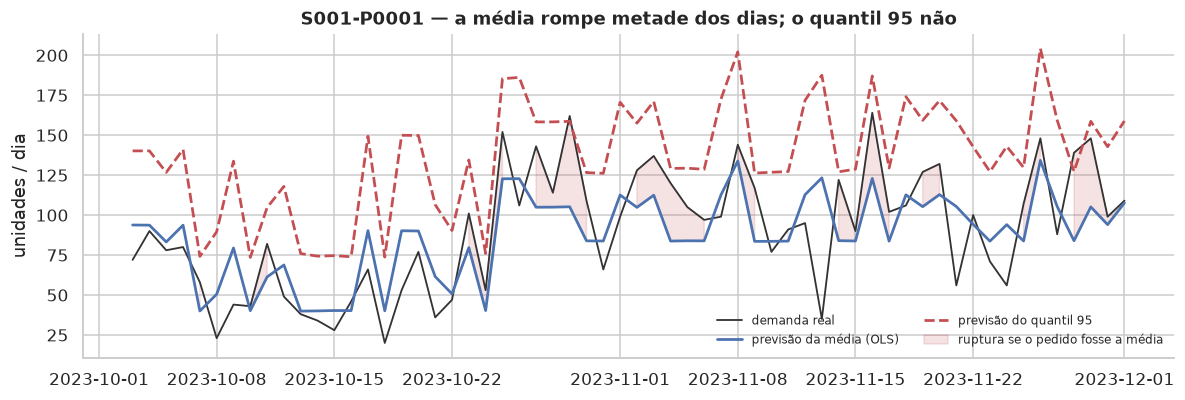

In [8]:
qr = sm.QuantReg(treino["demanda"].values, sm.add_constant(Xtr.values)).fit(q=0.95, max_iter=2000)
teste["pred_q95"] = np.maximum(qr.predict(sm.add_constant(desenho(teste, C.FEATURES, Xtr.columns).values)), 0)

serv_media = (teste["demanda"] <= teste["pred_ols"]).mean()
serv_q95 = (teste["demanda"] <= teste["pred_q95"]).mean()
print(f"Pedido = previsão da MÉDIA      → serviço atingido {serv_media:.1%}  (rompe {1-serv_media:.1%} dos dias)")
print(f"Pedido = previsão do QUANTIL 95 → serviço atingido {serv_q95:.1%}  (rompe {1-serv_q95:.1%} dos dias)")
print(f"\nCusto da folga: o quantil pede em média {(teste['pred_q95']-teste['pred_ols']).mean():.0f} unidades a mais por SKU-dia.")

sku = teste["sku"].iloc[0]
v = teste[teste["sku"] == sku].sort_values("data").head(60)
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(v["data"], v["demanda"], color="#333", lw=1.2, label="demanda real")
ax.plot(v["data"], v["pred_ols"], color="#4C72B0", lw=1.8, label="previsão da média (OLS)")
ax.plot(v["data"], v["pred_q95"], color="#C44E52", lw=1.8, ls="--", label="previsão do quantil 95")
ax.fill_between(v["data"], v["pred_ols"], v["demanda"], where=v["demanda"] > v["pred_ols"],
                color="#C44E52", alpha=0.16, label="ruptura se o pedido fosse a média")
ax.set_title(f"{sku} — a média rompe metade dos dias; o quantil 95 não")
ax.set_ylabel("unidades / dia"); ax.legend(frameon=False, fontsize=8, ncol=2)
sns.despine(); plt.tight_layout(); plt.show()

Acompanhamos um SKU ao longo de 60 dias. A linha preta é a demanda real; a azul, a previsão da média; a vermelha tracejada, a previsão do quantil 95. A área sombreada marca os dias em que a demanda superou a previsão da média — cada um deles seria uma ruptura se o pedido fosse a média.

Um pedido igual à previsão da média atende **50,9%** dos dias — rompe praticamente um dia em cada dois. É a média funcionando como esperado, e é operacionalmente inaceitável.

A mesma regressão linear, treinada com *pinball loss* em τ = 0,95, atinge **94,5%** de serviço. Nada mudou além da função de perda: neste problema, **a escolha do alvo pesa mais que a escolha do modelo**. O alvo das três trilhas passa a ser, portanto, o quantil, e τ vira o parâmetro de ajuste do negócio.

## 9. Resultados em três níveis de serviço

Mesmo motor das demais trilhas: a previsão de ponto vira pedido por calibração de resíduos por SKU, e o efeito é medido em reais contra a operação atual, em três níveis de τ. Método idêntico nas três, o que torna a comparação legítima.

In [9]:
base = C.baseline_atual(df, teste)
print(f"Operação ATUAL — ruptura {base['ruptura']:.1%} | "
      f"venda perdida R$ {base['perda']/1e6:.2f} M/ano | capital R$ {base['capital']/1e6:.2f} M\n")

pred_q = C.calibrador_residual(treino, teste, "pred_ols")     # previsão → pedido no nível τ
tri = C.tres_niveis(df, teste, base, pred_q)
frente = C.fronteira(df, teste, base, pred_q)
print(C.tabela_niveis(base, tri).to_markdown(index=False, tablefmt="grid"))

Operação ATUAL — ruptura 13.3% | venda perdida R$ 12.48 M/ano | capital R$ 1.92 M

+---------------------------------+----------------------+------------------+-------------------+
|                                 | Econômico (τ=0.85)   | Médio (τ=0.95)   | Seguro (τ=0.99)   |
+=================================+======================+==================+===================+
| nível de serviço-alvo (τ)       | 86%                  | 95%              | 99%               |
+---------------------------------+----------------------+------------------+-------------------+
| risco de ruptura                | 14.1%                | 4.5%             | 0.9%              |
+---------------------------------+----------------------+------------------+-------------------+
| venda perdida / ano             | R$ 7.23 M            | R$ 2.12 M        | R$ 0.41 M         |
+---------------------------------+----------------------+------------------+-------------------+
| → economia vs. hoje             |

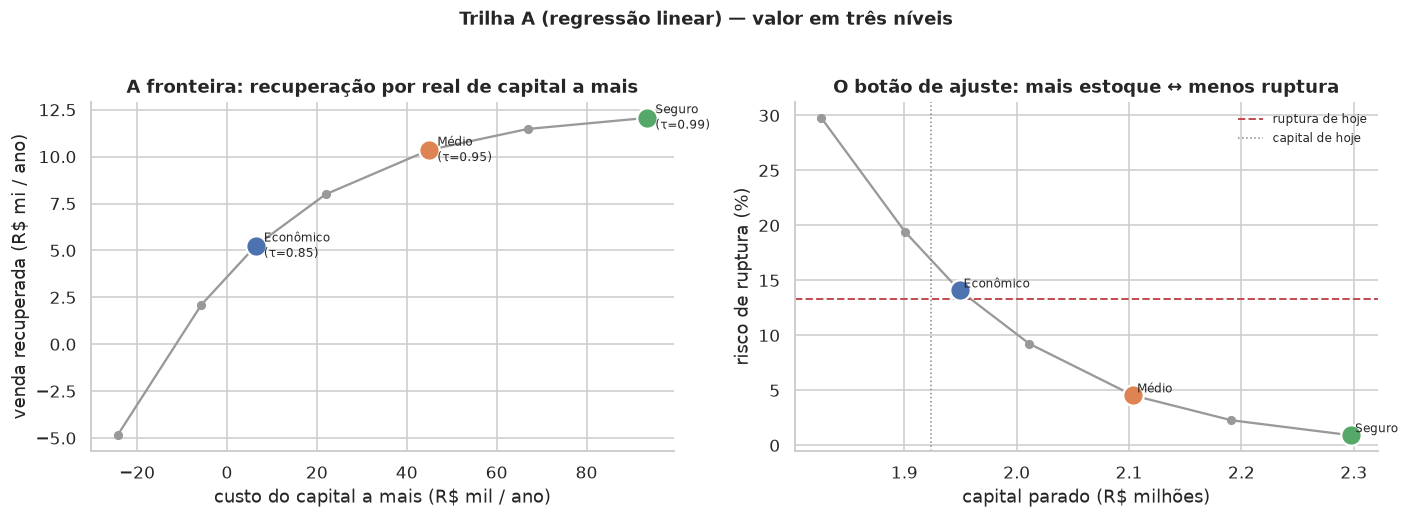

Previsões salvas em resultados/A_regressaoLinear.csv | RMSSE = 0.6488


In [10]:
C.grafico_resultados(base, frente, tri, titulo="Trilha A (regressão linear) — valor em três níveis")

# Salva as previsões de teste para a comparação em 08_fase1_conclusoes
C.salva_resultado("A_regressaoLinear", teste, "pred_ols", round(float(rmsse_A), 4))
print("Previsões salvas em resultados/A_regressaoLinear.csv | RMSSE =", round(float(rmsse_A), 4))

À esquerda, a fronteira: cada ponto é um valor de τ, com o custo de capital adicional no eixo horizontal e a venda recuperada no vertical; os três pontos coloridos são os níveis nomeados. À direita, o mesmo *trade-off* visto pelo que o gestor controla: mais capital parado, menos risco de ruptura.

Mesmo o modelo mais simples do projeto, calibrado a 95% de serviço, recupera a maior parte da venda perdida a um custo de capital de poucas dezenas de milhares de reais por ano.

Registramos o resultado por ser contraintuitivo: a maior parte do valor não vem do modelo, vem de mudar o alvo do pedido e de alocar o estoque nos itens certos. O que as trilhas seguintes disputam é a fatia restante — real, porém menor do que o senso comum sugere. Medir isso antes de treinar qualquer rede é o que nos impede de confundir sofisticação com resultado.

## 10. Conclusões

**1. A linear é um modelo de verdade.** RMSSE 0,649 contra 0,797 do melhor benchmark, com 22 colunas e ajuste instantâneo. Fica registrado o piso que as trilhas seguintes precisam bater com margem.

**2. Os coeficientes são legíveis.** Epidemia −43 un./dia, promoção +29, sortimento e clima coerentes, lojas indistinguíveis. Os mesmos efeitos da fase 0a, agora ajustados simultaneamente.

**3. A limitação é de forma, não de ajuste.** O modelo só desenha retas paralelas, com vão fixo de 43 unidades, contra vãos observados que vão de 74 (`Toys`) a −1 (`Clothing`).

**4. Três das quatro suposições falharam, e cada falha virou decisão de projeto.**

| suposição | veredito | consequência | § |
|---|---|---|---|
| preditores honestos | respeitada por decisão | o nível de preço vale zero; o desvio do dia vale −37% de RMSSE e é vazamento → preço proibido nas três trilhas | 4 |
| erro constante | falha (2,0×, cauda à direita) | margem proporcional ao contexto, calibrada por SKU | 5 |
| aditividade | falha (viés de 35 un.) | modelo que descubra interações sozinho → árvores | 3, 6 |
| alvo = média | falha (serviço de 51%) | alvo = quantil; τ vira o botão do negócio | 8 |

**5. Duas hipóteses foram descartadas cedo.** *One-hot* de SKU não paga suas 100 colunas — mas deixa em aberto a representação densa, que a Trilha C testa. E o histórico quase não paga: coeficiente +0,10, autocorrelação 0,24. Ambas custaram segundos aqui e teriam custado horas de rede depois.

**6. A maior parte do valor não estava no modelo.** O pedido calibrado a 95% já recupera milhões com a linear, o que muda como se lê o resultado das trilhas seguintes.

### O que esta trilha pediu às próximas

> **[Trilha B](06_fase1b_gradientBoosting.ipynb):** um modelo que descubra interações sozinho (§ 6) e preveja quantil nativamente (§ 8), com os mesmos preditores (§ 4).
>
> **[Trilha C](07_fase1c_redeNeural.ipynb):** uma representação densa de categóricas onde o *one-hot* falhou (§ 7), mantido o resto igual.

Nenhuma das duas é escolhida por ser moderna. Cada uma responde a uma medição feita aqui.